In [1]:
#Startup Autopsy: What Actually Kills Funded Indian Startups
#Author: Shreya Mishra  |  Computer Science, Chandigarh University

#Every year, dozens of Indian startups that raised real venture capital shut down. 
#Most retrospectives on this treat it as one story: "funding winter." 
#This notebook builds a small, hand-compiled dataset of 52 funded Indian startups that shut down between 2023 and 2025....
#with sector, funding raised, founding year, shutdown year, and the founders' own stated reason for closing,
#to ask a more specific question:

#Does why a startup dies depend on its sector, its funding level, or the year it died? 
#And does raising more money actually buy survival — or just a longer runway to the same outcome?

In [4]:
#Source: All 52 startups are drawn from Inc42's annual "Startup Graveyard" reports for 2023, 2024, and 2025:
#India's largest startup-focused business media outlet. 
#Each entry includes the startup's own public statement (LinkedIn post, press interview, or Inc42 reporting) 
#on why it shut down.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/shreyaavatsa/Desktop/startup_shutdowns_india.csv')
df['lifespan_years'] = df['shutdown_year'] - df['founded_year']
print(f'{len(df)} startups | {df["shutdown_year"].min()}–{df["shutdown_year"].max()} | {df["funding_usd_mn"].notna().sum()} with disclosed funding')
df.head()

52 startups | 2023–2025 | 34 with disclosed funding


,name,sector,founded_year,shutdown_year,funding_usd_mn,primary_cause,city,source_year_report,lifespan_years
0,Anar,Enterprise SaaS,2020,2023,6.20,No PMF / Low Retention,Bengaluru,2023,3
1,Belora Cosmetics,D2C Consumer,2019,2023,NaN,Funding Crunch,Delhi NCR,2023,4
2,Bluepad,Media & Content,2020,2023,0.22,No PMF / Weak Monetisation,Bengaluru,2023,3
3,ConnectedH,Healthtech,2018,2023,2.50,No PMF / Market Fit,Bengaluru,2023,5
4,DUX Education,Edtech,2020,2023,0.24,Funding Crunch,Bengaluru,2023,3


In [ ]:
#2. From specific reasons to broad categories
#Founders rarely say just "we ran out of money." 
#The raw primary_cause field has 46 distinct values for 52 startups 
#(e.g. "Cash Burn / Flawed Biz Model", "Regulatory (RBI UPI Ban)"). 
#To find patterns, I grouped these into 7 cause categories using keyword rules, 
#prioritized so a startup with multiple contributing factors (e.g. "Funding Crunch / Regulatory")
#is bucketed by the most structurally fundamental cause first:
#Regulatory Shock → Founder/Legal → Capital/Funding → No PMF → Weak Business Model → Scaling Failure.

In [6]:
def categorize(cause: str) -> str:
    c = cause.lower()
    if 'regulatory' in c:
        return 'Regulatory Shock'
    if 'founder' in c or 'insolvency' in c or 'legal turmoil' in c or 'acquirer' in c:
        return 'Founder / Legal / Insolvency'
    if 'funding crunch' in c or 'no follow-on' in c or 'cash burn' in c:
        return 'Capital / Funding Crunch'
    if 'pmf' in c or 'traction' in c or 'retention' in c:
        return 'No Product-Market Fit'
    if 'business model' in c or 'unit economics' in c or 'biz model' in c or 'commoditised' in c or 'margins' in c:
        return 'Weak Business Model / Economics'
    if 'scal' in c or 'pivot' in c or 'demand' in c or 'debt' in c:
        return 'Scaling / Execution Failure'
    return 'Other'

df['cause_category'] = df['primary_cause'].apply(categorize)
df['cause_category'].value_counts()

cause_category
Capital / Funding Crunch           16
No Product-Market Fit              10
Regulatory Shock                   10
Scaling / Execution Failure         5
Founder / Legal / Insolvency        5
Weak Business Model / Economics     4
Other                               2
Name: count, dtype: int64

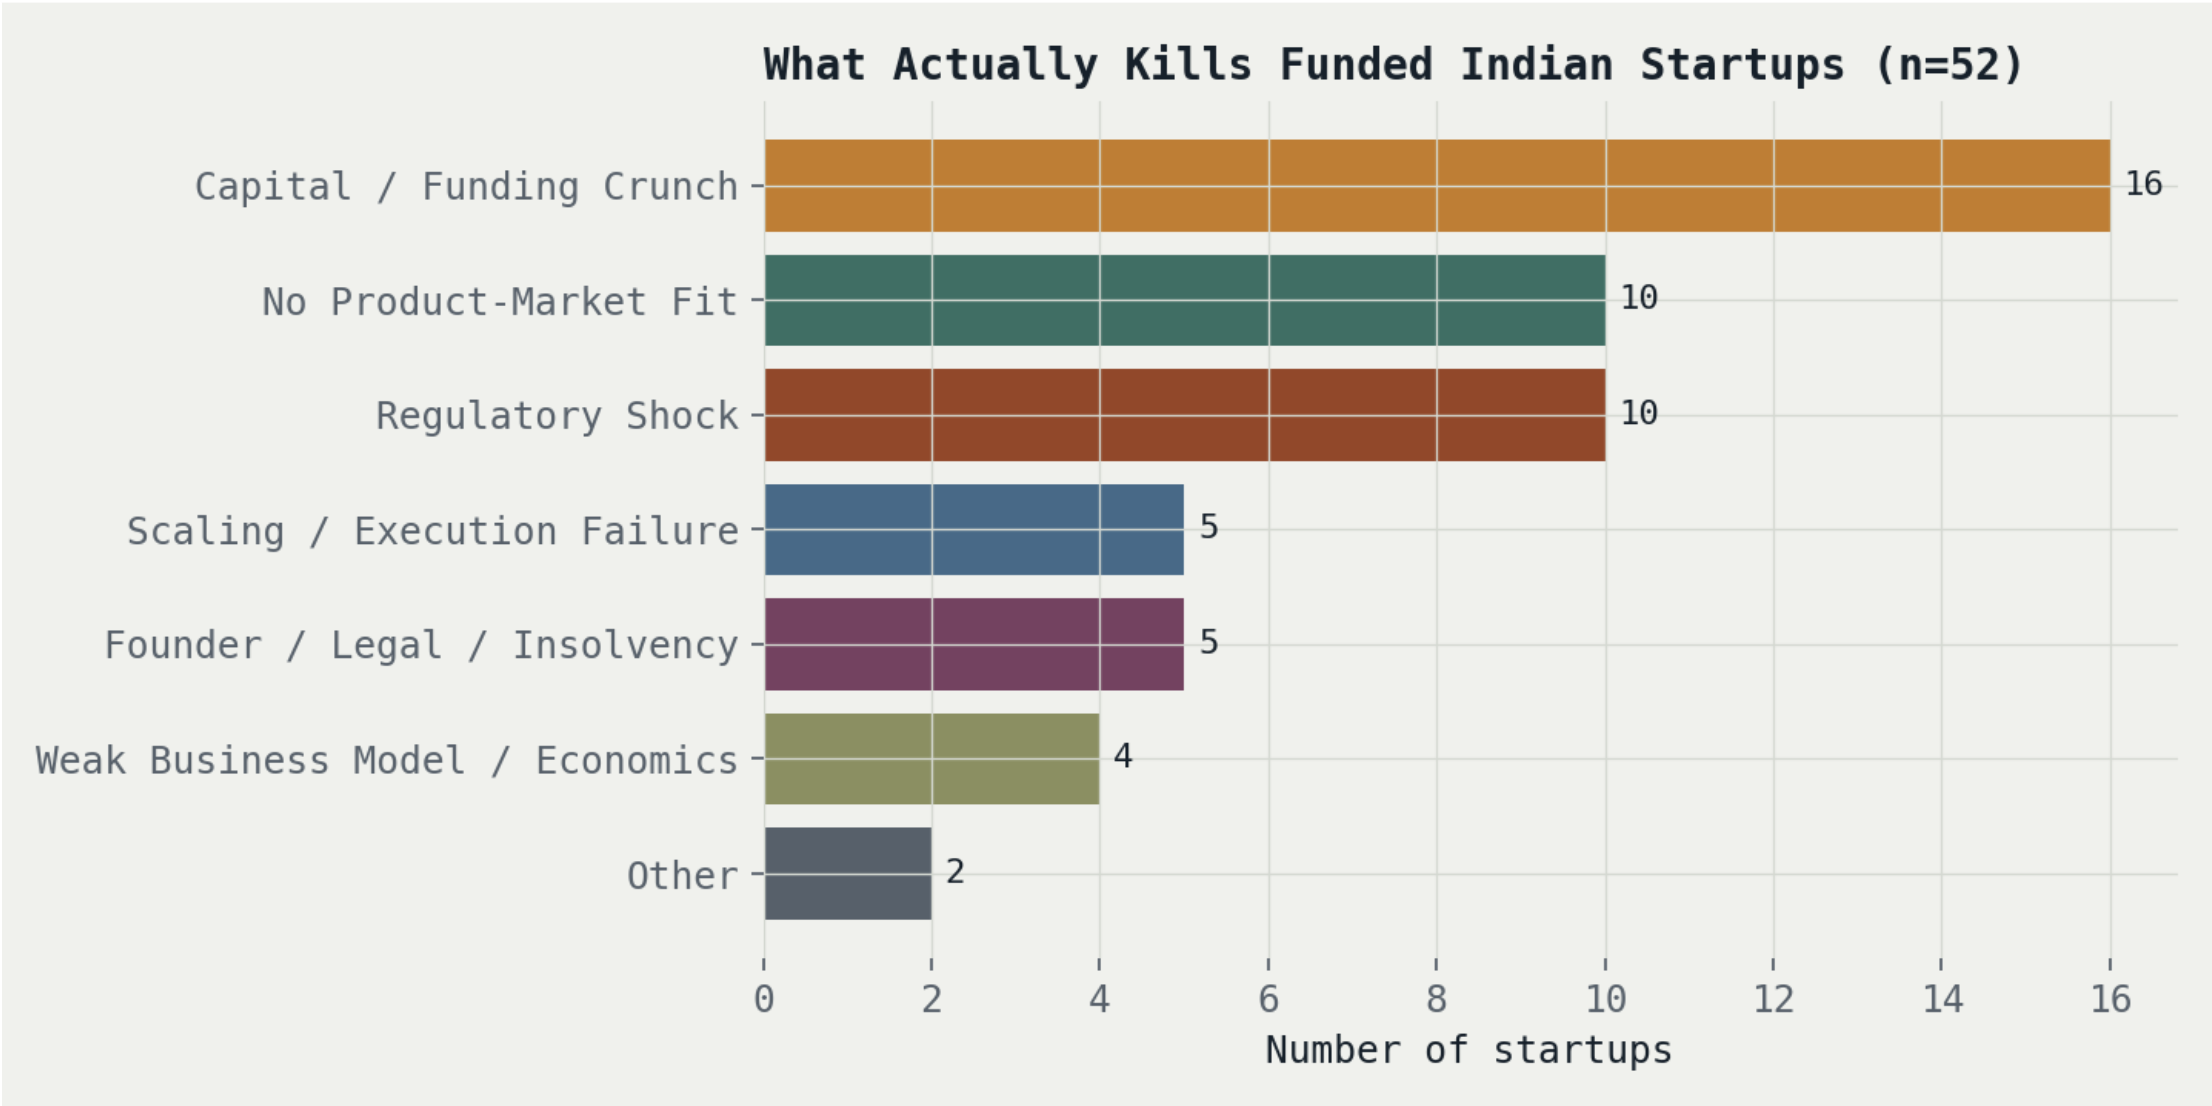

#3. Does more funding buy survival — or just time?

In [8]:
fdf = df.dropna(subset=['funding_usd_mn']).copy()
fdf['log_funding'] = np.log1p(fdf['funding_usd_mn'])
corr = np.corrcoef(fdf['log_funding'], fdf['lifespan_years'])[0, 1]
print(f'Correlation (log funding vs. years survived): r = {corr:.2f}')

Correlation (log funding vs. years survived): r = 0.62


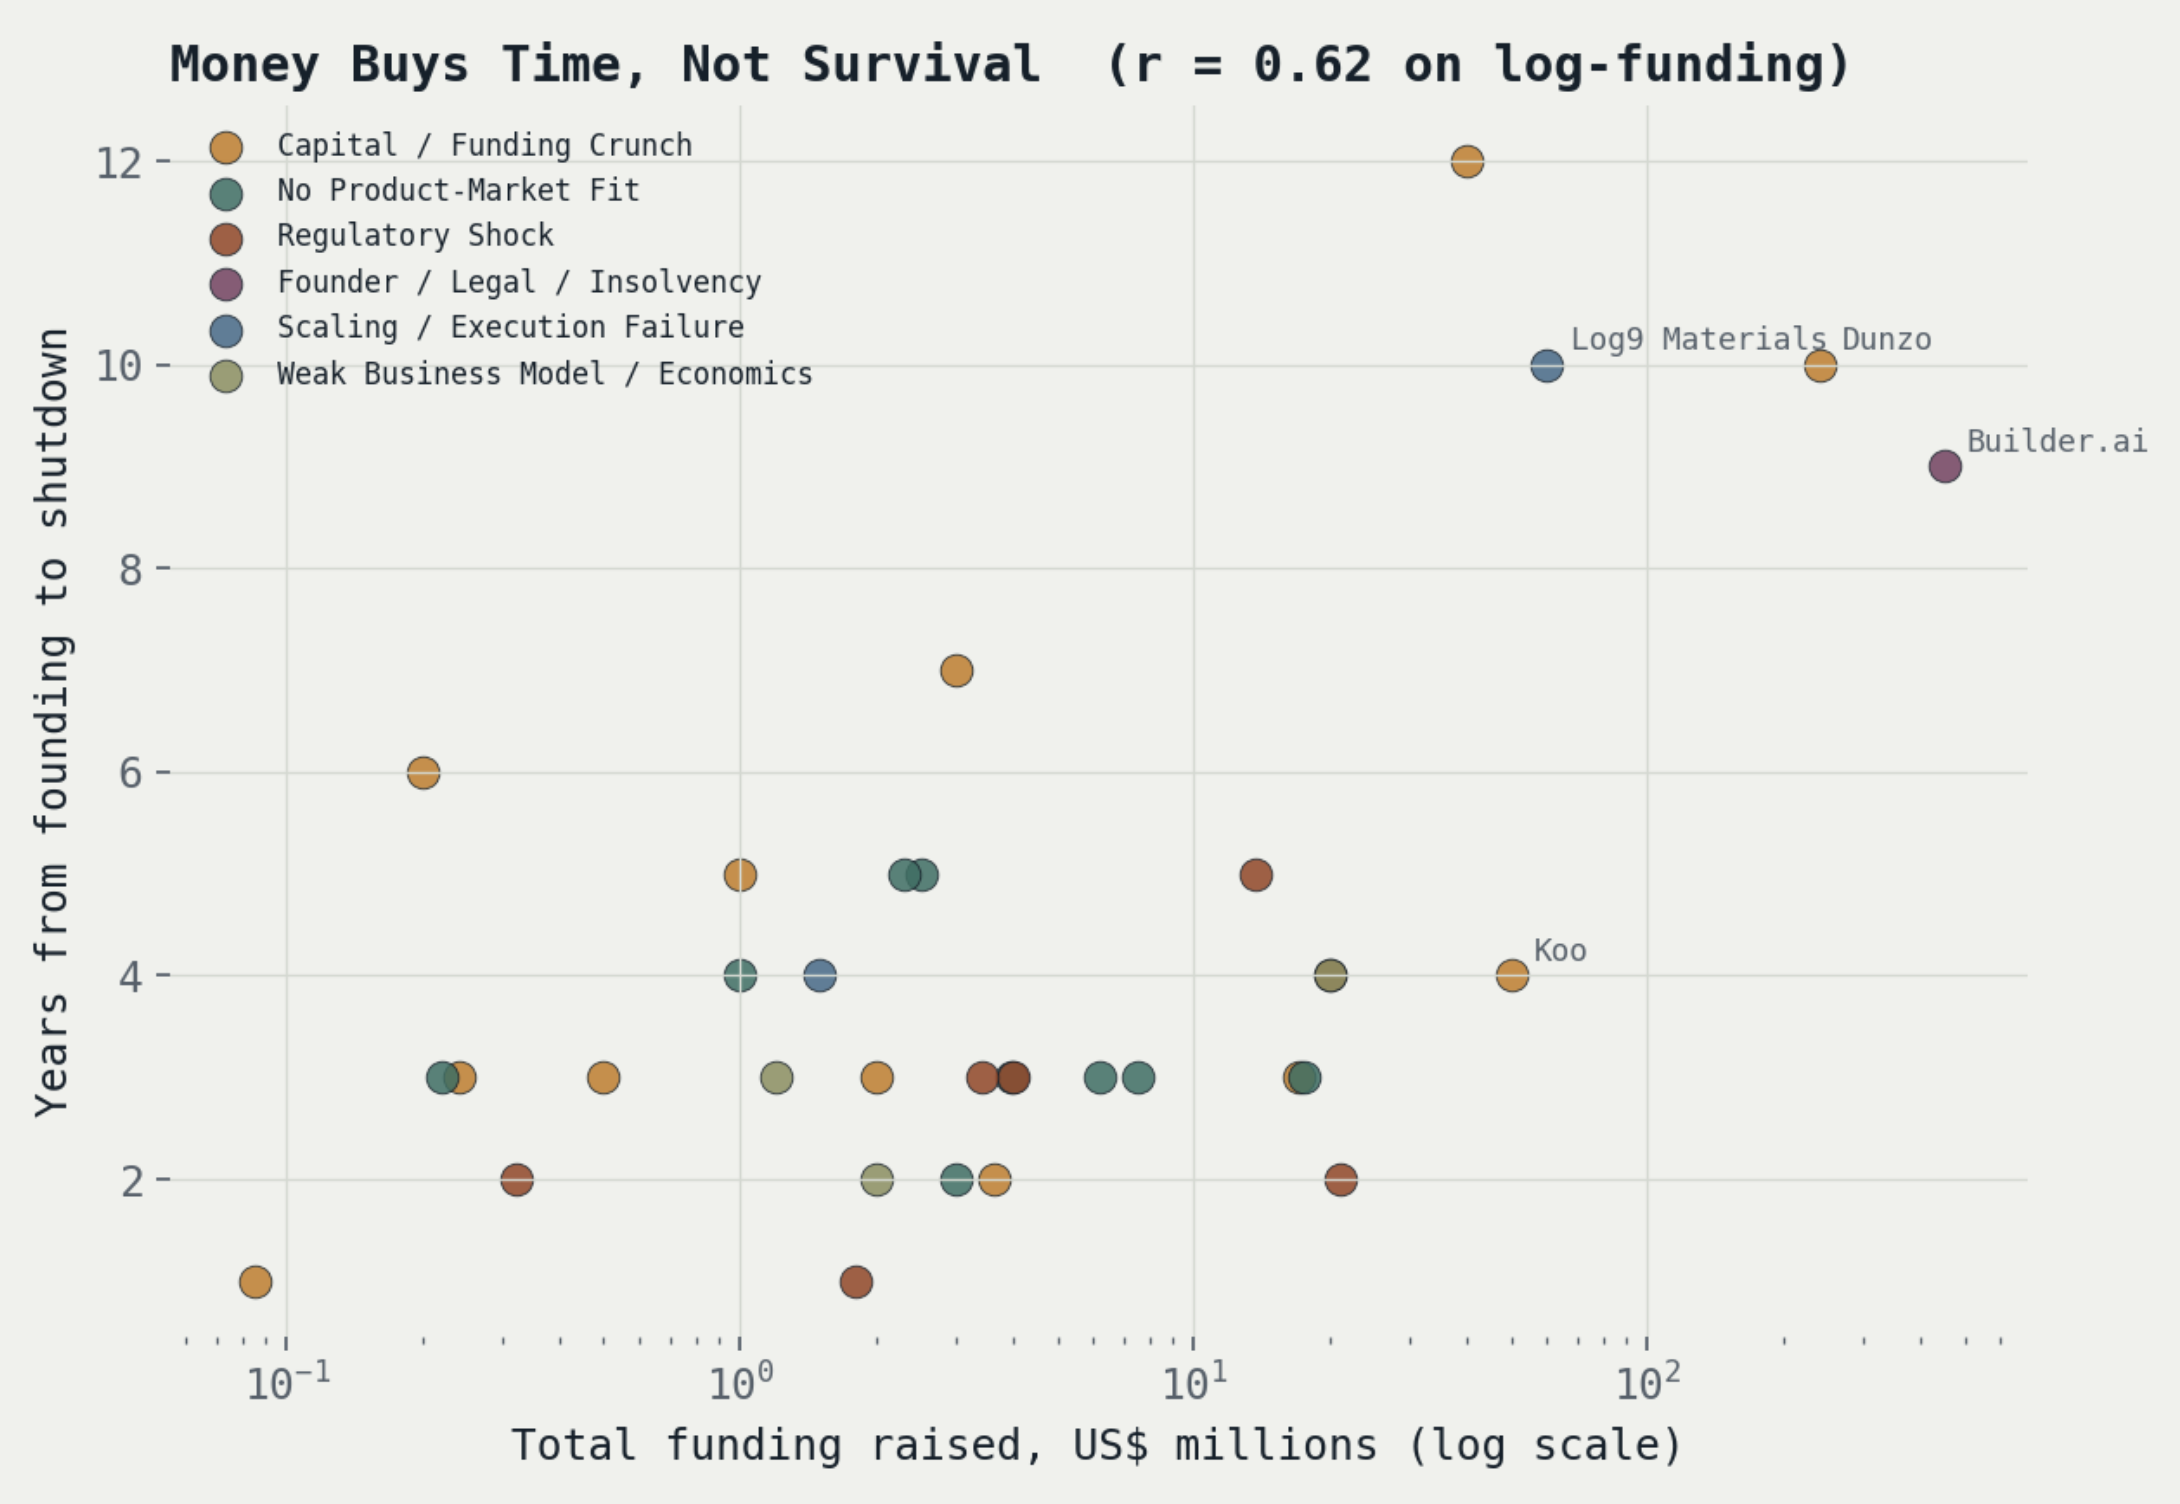

In [9]:
#A moderate positive correlation (r = 0.62 on log-funding).
#This confirms the intuitive story but with an important twist visible in the scatter below: 
#money buys runway, not survival. 

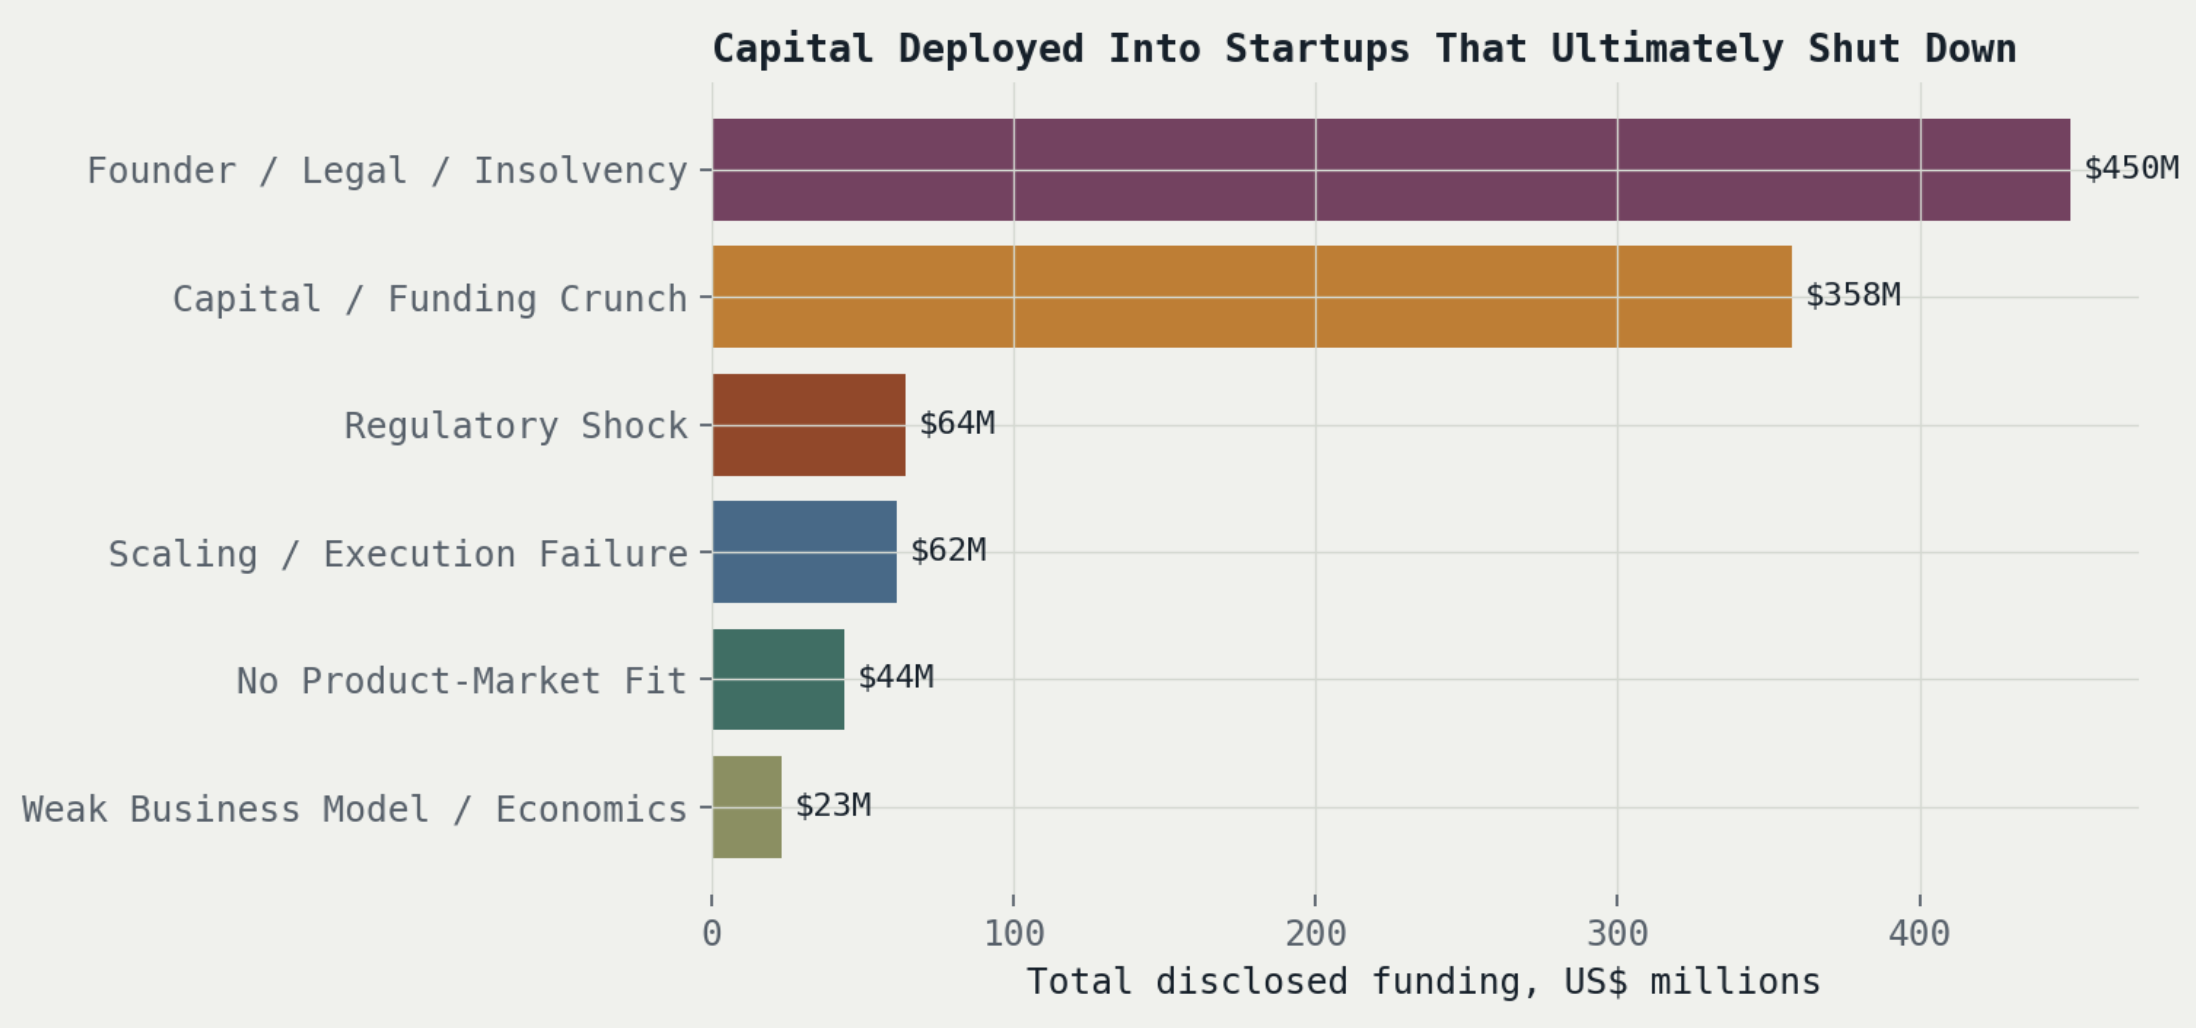

In [1]:
# Key findings
#Capital crunch is the single biggest documented cause of dath (31%)...
#but Product Market Fit failure and Regulatory Shock are statistically tied for second (19% each).
#Regulation is not a footnote; it's a top-three killer.
#Regulatory risk is a constant background hazard, not a fading pandemic-era problem.
#it caused 4, 2, and 4 shutdowns in 2023, 2024, and 2025 respectively, showing no sign of tapering off as the funding winter thaws.
#Founder / governance failures are a distinctly 2025 phenomenon in this dataset (0 → 0 → 5), 
#surfacing only as the ecosystem's highest-profile, longest-running companies reach the scale where 
#fraud and mismanagement become visible and material.
#Funding buys time, not survival (r = 0.62 on log-funding vs. lifespan)..
#a real but moderate relationship. Sector and cause of death explain the outcome better than cheque size alone.
#Some sectors have a single dominant killer. Gaming & RMG has essentially one cause of death: regulation.
#Enterprise SaaS and Healthtech share another: no one wanted to buy the product.